In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

%matplotlib inline

df = pd.read_csv('../data/2025-yl-rayl-sistemler-istasyon-bazl-yolcu-ve-yolculuk-saylar.csv') 

# İlk 5 satır
df.head()

,transaction_year;transaction_month;transaction_day;line;station_name;station_number;town;longitude;latitude;passage_cnt;passanger_cnt
0,2025;5;26;TF2-TELEFERIK EYUP PIYERLOTI;Pierlot...
1,2025;9;1;TF2-TELEFERIK EYUP PIYERLOTI;Eyüp;EYU...
2,2025;10;25;TF2-TELEFERIK EYUP PIYERLOTI;Pierlo...
3,2025;12;14;TF2-TELEFERIK EYUP PIYERLOTI;Pierlo...
4,2025;5;7;TF2-TELEFERIK EYUP PIYERLOTI;Pierloti...


In [16]:
# =============================================================================
# 1. VERİYİ YÜKLE
# =============================================================================

FILE_PATH = "../data/2025-yl-rayl-sistemler-istasyon-bazl-yolcu-ve-yolculuk-saylar.csv"  # Dosya yolunu güncelle

# Önce birkaç satıra bakarak ayırıcıyı kontrol ediyoruz
try:
    df = pd.read_csv(FILE_PATH, sep="\t", encoding="utf-8")
    if df.shape[1] == 1:
        # Tab ile ayrılmadıysa virgül dene
        df = pd.read_csv(FILE_PATH, sep=";", encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(FILE_PATH, sep="\t", encoding="latin-1")

print("=" * 60)
print("VERİ YÜKLEME TAMAMLANDI")
print("=" * 60)
print(f"Satır sayısı : {df.shape[0]:,}")
print(f"Sütun sayısı : {df.shape[1]}")
print(f"\nSütunlar: {list(df.columns)}\n")

# =============================================================================
# 2. EKSİK DEĞER (NaN) TESPİTİ
# =============================================================================

print("=" * 60)
print("EKSİK DEĞER ANALİZİ")
print("=" * 60)

nan_sayisi = df.isnull().sum()
nan_yuzdesi = (df.isnull().mean() * 100).round(2)

nan_rapor = pd.DataFrame({
    "Eksik Sayı": nan_sayisi,
    "Eksik Yüzde (%)": nan_yuzdesi
})

print(nan_rapor.to_string())
print(f"\nToplam eksik değer: {df.isnull().sum().sum():,}")

# Hiç eksik olmayan sütunları da belirt
temiz_sutunlar = nan_sayisi[nan_sayisi == 0].index.tolist()
print(f"Eksik değeri olmayan sütunlar: {temiz_sutunlar}")

# =============================================================================
# 3. VERİ TİPİ DÖNÜŞÜMÜ
# =============================================================================

print("\n" + "=" * 60)
print("VERİ TİPİ DÖNÜŞÜMÜ")
print("=" * 60)
print("Dönüşüm öncesi tipler:")
print(df.dtypes.to_string())

# --- Tarih sütunları → int (yıl, ay, gün tam sayı olmalı) ---
for col in ["transaction_year", "transaction_month", "transaction_day"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")  # Int64: NaN destekli int

# --- Tam sayı sütunları ---
for col in ["station_number", "passage_cnt", "passanger_cnt"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# --- Koordinat sütunları → float ---
for col in ["longitude", "latitude"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# --- Metin sütunları → string (boş hücreleri NaN olarak tut) ---
for col in ["line", "station_name", "town"]:
    if col in df.columns:
        df[col] = df[col].astype("string")

# --- Tarih sütunlarını birleştirip gerçek datetime oluştur ---
try:
    df["date"] = pd.to_datetime(
        df[["transaction_year", "transaction_month", "transaction_day"]]
        .rename(columns={
            "transaction_year": "year",
            "transaction_month": "month",
            "transaction_day": "day"
        }),
        errors="coerce"
    )
    print("\n✓ 'date' sütunu oluşturuldu (datetime64 formatında)")
except Exception as e:
    print(f"\n'date' sütunu oluşturulamadı: {e}")

print("\nDönüşüm sonrası tipler:")
print(df.dtypes.to_string())

# =============================================================================
# 4. ÖZET RAPOR
# =============================================================================

print("\n" + "=" * 60)
print("GENEL ÖZET")
print("=" * 60)
print(df.describe(include="all").T.to_string())

# =============================================================================
# 5. TEMİZLENMİŞ VERİYİ KAYDET (opsiyonel)
# =============================================================================

OUTPUT_PATH = "rayli_sistemler_temiz.csv"
df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"\n✓ Temizlenmiş veri '{OUTPUT_PATH}' olarak kaydedildi.")

VERİ YÜKLEME TAMAMLANDI
Satır sayısı : 135,783
Sütun sayısı : 11

Sütunlar: ['transaction_year', 'transaction_month', 'transaction_day', 'line', 'station_name', 'station_number', 'town', 'longitude', 'latitude', 'passage_cnt', 'passanger_cnt']

EKSİK DEĞER ANALİZİ
                   Eksik Sayı  Eksik Yüzde (%)
transaction_year            0             0.00
transaction_month           0             0.00
transaction_day             0             0.00
line                        0             0.00
station_name              728             0.54
station_number            728             0.54
town                      416             0.31
longitude               23858            17.57
latitude                23858            17.57
passage_cnt                 0             0.00
passanger_cnt               0             0.00

Toplam eksik değer: 49,588
Eksik değeri olmayan sütunlar: ['transaction_year', 'transaction_month', 'transaction_day', 'line', 'passage_cnt', 'passanger_cnt']

VERİ TİPİ 

✓ Grafik 'gunluk_ortalama_yolcu.png' olarak kaydedildi.


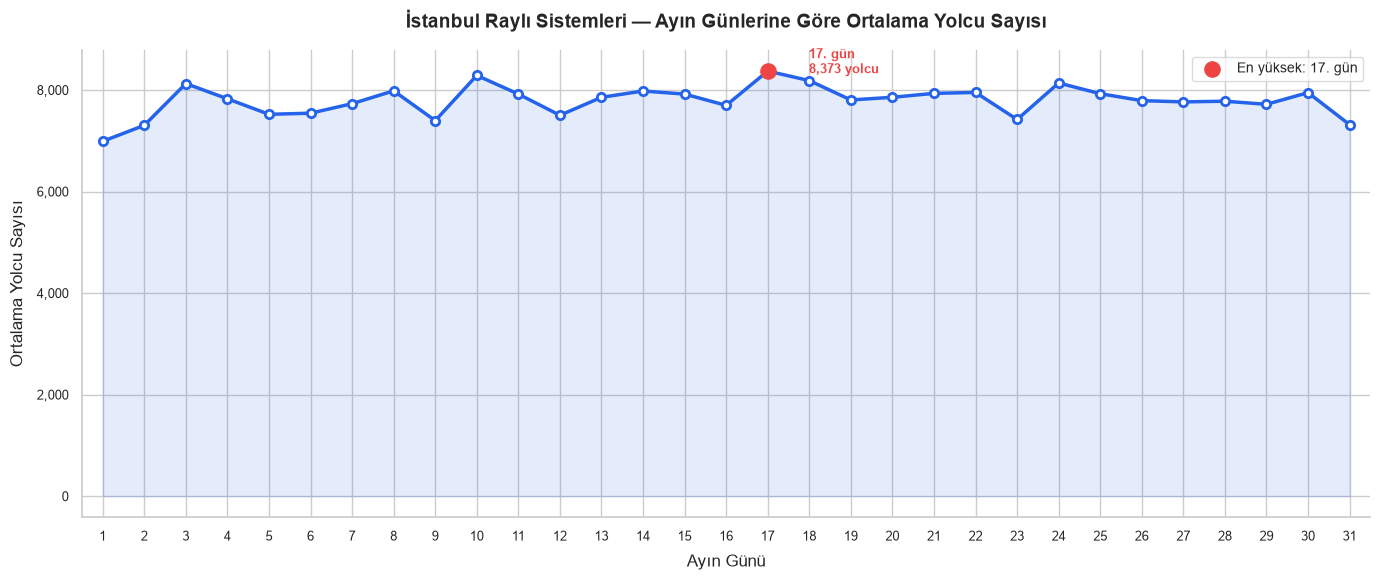

In [17]:
# ARAŞTIRMA SORUSU 1: AYIN HANGİ GÜNLERİNDE YOLCU SAYISI EN YÜKSEKTİR?

# =============================================================================
# 1. VERİYİ YÜKLE
# =============================================================================

FILE_PATH = "rayli_sistemler_temiz.csv"  # Dosya yolunu güncelle

df = pd.read_csv(FILE_PATH, sep=None, engine="python", encoding="utf-8-sig")

# Sütun adlarını temizle (baştaki/sondaki boşluk varsa)
df.columns = df.columns.str.strip()

# =============================================================================
# 2. VERİ HAZIRLAMA
# =============================================================================

df["transaction_day"] = pd.to_numeric(df["transaction_day"], errors="coerce")
df["passanger_cnt"]   = pd.to_numeric(df["passanger_cnt"],   errors="coerce")

df = df.dropna(subset=["transaction_day", "passanger_cnt"])
df["transaction_day"] = df["transaction_day"].astype(int)

# Gün bazında ortalama yolcu sayısı
gunluk = (
    df.groupby("transaction_day")["passanger_cnt"]
    .mean()
    .reset_index()
    .rename(columns={"transaction_day": "Gün", "passanger_cnt": "Ortalama Yolcu Sayısı"})
    .sort_values("Gün")
)

en_yuksek_gun = gunluk.loc[gunluk["Ortalama Yolcu Sayısı"].idxmax(), "Gün"]
en_yuksek_val = gunluk["Ortalama Yolcu Sayısı"].max()

# =============================================================================
# 3. GRAFİK
# =============================================================================

sns.set_theme(style="whitegrid", font_scale=1.1)

fig, ax = plt.subplots(figsize=(14, 6))

# Gölge alan
ax.fill_between(
    gunluk["Gün"],
    gunluk["Ortalama Yolcu Sayısı"],
    alpha=0.12,
    color="#2563EB"
)

# Ana çizgi
sns.lineplot(
    data=gunluk,
    x="Gün",
    y="Ortalama Yolcu Sayısı",
    ax=ax,
    color="#2563EB",
    linewidth=2.5,
    marker="o",
    markersize=6,
    markerfacecolor="white",
    markeredgewidth=2,
    markeredgecolor="#2563EB"
)

# En yüksek noktayı vurgula
ax.scatter(
    en_yuksek_gun,
    en_yuksek_val,
    color="#EF4444",
    s=120,
    zorder=5,
    label=f"En yüksek: {int(en_yuksek_gun)}. gün"
)
ax.annotate(
    f"  {int(en_yuksek_gun)}. gün\n  {en_yuksek_val:,.0f} yolcu",
    xy=(en_yuksek_gun, en_yuksek_val),
    xytext=(en_yuksek_gun + 0.8, en_yuksek_val * 0.995),
    fontsize=9.5,
    color="#EF4444",
    fontweight="bold"
)

# Eksen ayarları
ax.set_xlabel("Ayın Günü", fontsize=12, labelpad=8)
ax.set_ylabel("Ortalama Yolcu Sayısı", fontsize=12, labelpad=8)
ax.set_title(
    "İstanbul Raylı Sistemleri — Ayın Günlerine Göre Ortalama Yolcu Sayısı",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.set_xticks(range(1, 32))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9)

ax.legend(fontsize=10, framealpha=0.7)
ax.set_xlim(0.5, 31.5)

sns.despine(left=False, bottom=False)
plt.tight_layout()

# =============================================================================
# 4. KAYDET
# =============================================================================

OUTPUT = "gunluk_ortalama_yolcu.png"
plt.savefig(OUTPUT, dpi=150, bbox_inches="tight")
print(f"✓ Grafik '{OUTPUT}' olarak kaydedildi.")
plt.show()

✓ Grafik 'top10_hat_yolcu.png' olarak kaydedildi.


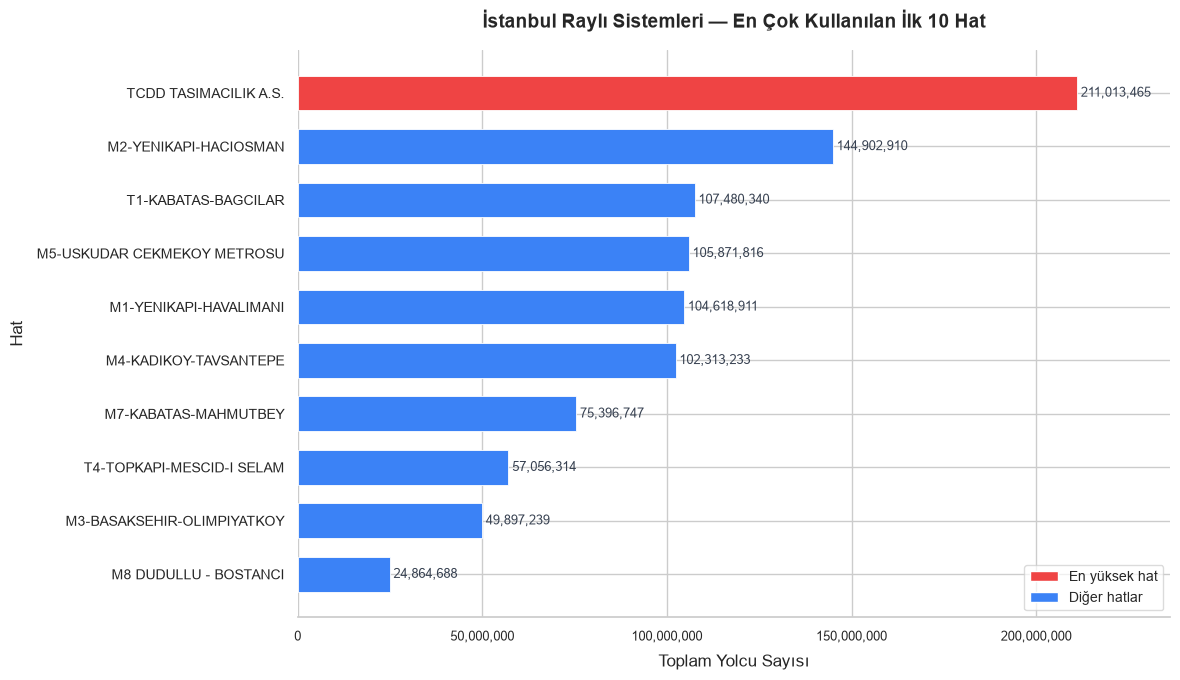

In [18]:
# ARAŞTIRMA SORUSU 2: EN ÇOK KULLANILAN İLK 10 ULAŞIM HATTI HANGİLERİDİR?

# =============================================================================
# 1. VERİYİ YÜKLE
# =============================================================================

FILE_PATH = "rayli_sistemler_temiz.csv"  # Dosya yolunu güncelle

df = pd.read_csv(FILE_PATH, sep=None, engine="python", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

# =============================================================================
# 2. VERİ HAZIRLAMA
# =============================================================================

df["passanger_cnt"] = pd.to_numeric(df["passanger_cnt"], errors="coerce")
df = df.dropna(subset=["line", "passanger_cnt"])

# Hat bazında toplam yolcu sayısı → ilk 10
top10 = (
    df.groupby("line")["passanger_cnt"]
    .sum()
    .reset_index()
    .rename(columns={"line": "Hat", "passanger_cnt": "Toplam Yolcu Sayısı"})
    .sort_values("Toplam Yolcu Sayısı", ascending=False)
    .head(10)
    .sort_values("Toplam Yolcu Sayısı", ascending=True)  # grafik için alt→üst
    .reset_index(drop=True)
)

en_yuksek_hat = top10["Toplam Yolcu Sayısı"].max()

# Renk: en yüksek çubuk vurgu rengi, diğerleri standart
renkler = [
    "#EF4444" if v == en_yuksek_hat else "#3B82F6"
    for v in top10["Toplam Yolcu Sayısı"]
]

# =============================================================================
# 3. GRAFİK
# =============================================================================

sns.set_theme(style="whitegrid", font_scale=1.1)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top10["Hat"],
    top10["Toplam Yolcu Sayısı"],
    color=renkler,
    edgecolor="white",
    linewidth=0.6,
    height=0.65
)

# Çubuk uçlarına değer etiketi
for bar, val in zip(bars, top10["Toplam Yolcu Sayısı"]):
    ax.text(
        bar.get_width() + top10["Toplam Yolcu Sayısı"].max() * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#374151"
    )

# Eksen ayarları
ax.set_xlabel("Toplam Yolcu Sayısı", fontsize=12, labelpad=8)
ax.set_ylabel("Hat", fontsize=12, labelpad=8)
ax.set_title(
    "İstanbul Raylı Sistemleri — En Çok Kullanılan İlk 10 Hat",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=9)

# X eksenini biraz genişlet (etiket taşmasın)
ax.set_xlim(0, top10["Toplam Yolcu Sayısı"].max() * 1.12)

# Lejant
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#EF4444", label="En yüksek hat"),
    Patch(facecolor="#3B82F6", label="Diğer hatlar"),
]
ax.legend(handles=legend_elements, fontsize=10, framealpha=0.7, loc="lower right")

sns.despine(left=True, bottom=False)
plt.tight_layout()

# =============================================================================
# 4. KAYDET
# =============================================================================

OUTPUT = "top10_hat_yolcu.png"
plt.savefig(OUTPUT, dpi=150, bbox_inches="tight")
print(f"✓ Grafik '{OUTPUT}' olarak kaydedildi.")
plt.show()

Not: Toplam 34 ilçe bulundu. En yoğun 20 ilçe gösteriliyor.
Pivot tablo boyutu: 20 ilçe × 31 gün
transaction_day       1        2        3        4        5        6   \
town                                                                    
Fatih            5517087  5694191  6311396  6071867  5820008  5841071   
Şişli            2388099  2754064  3156441  3036693  2836271  2848299   
Kadıköy          2585407  2659671  2881293  2786720  2696741  2698529   
Üsküdar          2490535  2577388  2859792  2734268  2628758  2653732   
Bakırköy         2158454  2201987  2430517  2369909  2305875  2297714   

transaction_day       7        8        9        10  ...       22       23  \
town                                                 ...                     
Fatih            6001970  6270384  5742213  6414533  ...  6205390  5839610   
Şişli            3011891  3032329  2782617  3255259  ...  3082757  2779649   
Kadıköy          2706998  2823879  2639754  2933377  ...  2832159  2732022   
Ü

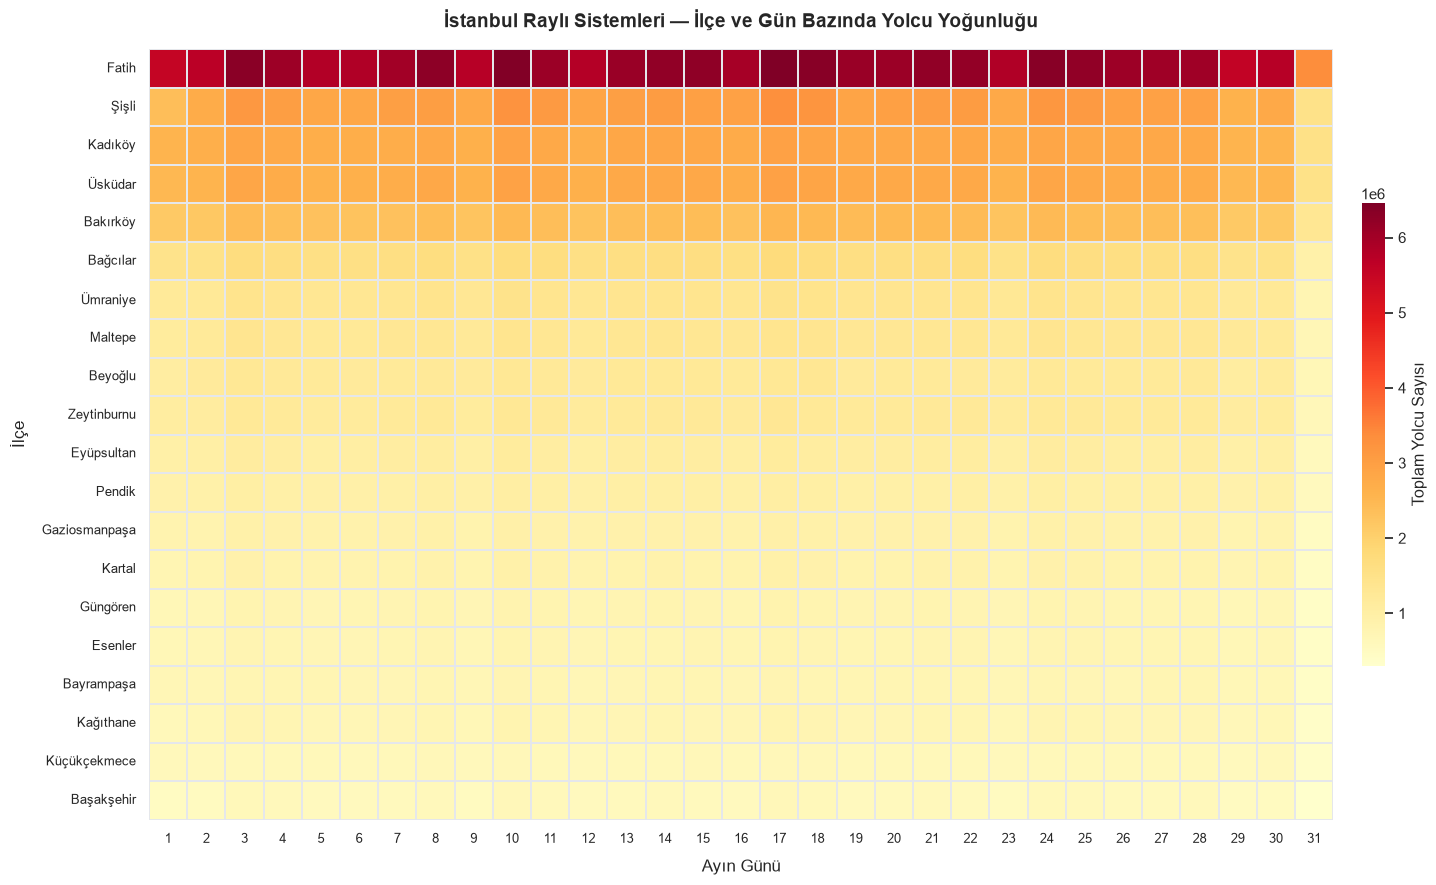

In [19]:
# ARAŞTIRMA SORUSU 3: YOLCU YOĞUNLUĞUNUN İLÇELER VE AYIN GÜNLERİ ARASINDAKİ İLİŞKİSİNİN MATRİS OLARAK GÖSTERİLMESİ 
# =============================================================================
# 1. VERİYİ YÜKLE
# =============================================================================

FILE_PATH = "rayli_sistemler_temiz.csv"  # Dosya yolunu güncelle

df = pd.read_csv(FILE_PATH, sep=None, engine="python", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

# =============================================================================
# 2. VERİ HAZIRLAMA
# =============================================================================

# Sütun adı "town" veya "towns" olabilir — ikisini de kontrol et
town_col = "town" if "town" in df.columns else "towns"

df["transaction_day"] = pd.to_numeric(df["transaction_day"], errors="coerce")
df["passanger_cnt"]   = pd.to_numeric(df["passanger_cnt"],   errors="coerce")
df = df.dropna(subset=[town_col, "transaction_day", "passanger_cnt"])
df["transaction_day"] = df["transaction_day"].astype(int)
df[town_col] = df[town_col].astype(str).str.strip().str.title()

# groupby → özet tablo (pivot)
pivot = (
    df.groupby([town_col, "transaction_day"])["passanger_cnt"]
    .sum()
    .reset_index()
    .pivot(index=town_col, columns="transaction_day", values="passanger_cnt")
)

# Toplam yolcuya göre ilçeleri büyükten küçüğe sırala
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

# Çok fazla ilçe varsa ilk 20'yi al (grafik okunabilirliği)
MAX_ILCE = 20
if len(pivot) > MAX_ILCE:
    print(f"Not: Toplam {len(pivot)} ilçe bulundu. En yoğun {MAX_ILCE} ilçe gösteriliyor.")
    pivot = pivot.head(MAX_ILCE)

# Eksik gün hücrelerini 0 ile doldur
pivot = pivot.fillna(0)

print(f"Pivot tablo boyutu: {pivot.shape[0]} ilçe × {pivot.shape[1]} gün")
print(pivot.head())

# =============================================================================
# 3. HEATMAP
# =============================================================================

sns.set_theme(style="white", font_scale=0.95)

fig_height = max(8, len(pivot) * 0.45)
fig, ax = plt.subplots(figsize=(16, fig_height))

sns.heatmap(
    pivot,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="#e5e7eb",
    annot=False,          # hücre sayıları çok kalabalık olur; True yapabilirsin
    fmt=".0f",
    cbar_kws={
        "label": "Toplam Yolcu Sayısı",
        "shrink": 0.6,
        "pad": 0.02
    }
)

# Eksen etiketleri
ax.set_xlabel("Ayın Günü", fontsize=12, labelpad=10)
ax.set_ylabel("İlçe", fontsize=12, labelpad=10)
ax.set_title(
    "İstanbul Raylı Sistemleri — İlçe ve Gün Bazında Yolcu Yoğunluğu",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.tick_params(axis="x", labelsize=9, rotation=0)
ax.tick_params(axis="y", labelsize=9, rotation=0)

plt.tight_layout()

# =============================================================================
# 4. KAYDET
# =============================================================================

OUTPUT = "ilce_gun_heatmap.png"
plt.savefig(OUTPUT, dpi=150, bbox_inches="tight")
print(f"✓ Grafik '{OUTPUT}' olarak kaydedildi.")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_26324\2164602458.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


✓ Grafik 'hat_yolcu_boxplot.png' olarak kaydedildi.

── Outlier Özeti (Hat Başına) ──


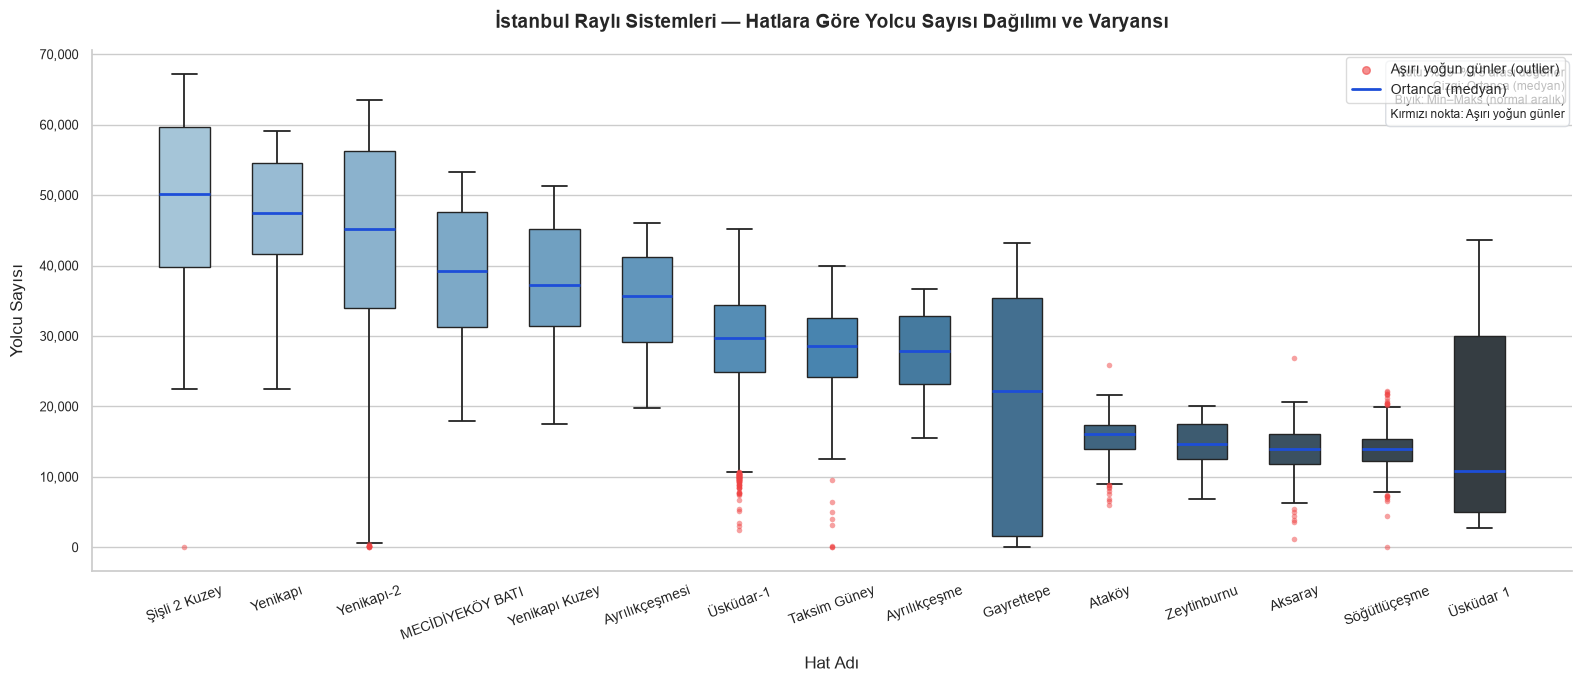

In [20]:
# ARAŞTIRMA SORUSU 4: FARKLI HATLARIN YOLCU SAYILARI ARASINDAKİ DAĞILIMIN VE VARYANSIN KARŞILAŞTIRILMASI VE
# EKSTREM YOĞUN GÜNLERİN TESPİT EDİLMESİ
# =============================================================================
# 1. VERİYİ YÜKLE
# =============================================================================

FILE_PATH = "rayli_sistemler_temiz.csv"  # Dosya yolunu güncelle

df = pd.read_csv(FILE_PATH, sep=None, engine="python", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

# =============================================================================
# 2. VERİ HAZIRLAMA
# =============================================================================

df["passanger_cnt"] = pd.to_numeric(df["passanger_cnt"], errors="coerce")
df = df.dropna(subset=["line", "passanger_cnt"])
df["line"] = df["line"].astype(str).str.strip().str.upper()

# Hat başına toplam yolcu — en yoğun ilk 15 hattı seç
top_hatlar = (
    df.groupby("station_name")["passanger_cnt"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)

df_plot = df[df["station_name"].isin(top_hatlar)].copy()

# Ortanca değere göre hat sıralaması (soldan sağa azalan)
hat_sirasi = (
    df_plot.groupby("station_name")["passanger_cnt"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# =============================================================================
# 3. BOX PLOT
# =============================================================================

sns.set_theme(style="whitegrid", font_scale=1.05)

fig, ax = plt.subplots(figsize=(16, 7))

# Renk paleti
palette = sns.color_palette("Blues_d", n_colors=len(hat_sirasi))

sns.boxplot(
    data=df_plot,
    x="station_name",
    y="passanger_cnt",
    order=hat_sirasi,
    palette=palette,
    width=0.55,
    flierprops=dict(
        marker="o",
        markerfacecolor="#EF4444",
        markersize=4,
        alpha=0.5,
        markeredgewidth=0
    ),
    medianprops=dict(color="#1D4ED8", linewidth=2),
    whiskerprops=dict(linewidth=1.3),
    capprops=dict(linewidth=1.3),
    ax=ax
)

# Outlier açıklaması
ax.scatter([], [], color="#EF4444", s=30, alpha=0.6,
           label="Aşırı yoğun günler (outlier)")
ax.plot([], [], color="#1D4ED8", linewidth=2, label="Ortanca (medyan)")
ax.legend(fontsize=10, framealpha=0.7, loc="upper right")

# Eksen ayarları
ax.set_xlabel("Hat Adı", fontsize=12, labelpad=10)
ax.set_ylabel("Yolcu Sayısı", fontsize=12, labelpad=10)
ax.set_title(
    "İstanbul Raylı Sistemleri — Hatlara Göre Yolcu Sayısı Dağılımı ve Varyansı",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="x", labelsize=10, rotation=20)
ax.tick_params(axis="y", labelsize=9)

# Açıklama kutusu
aciklama = (
    "Kutu: %25–%75 arası değerler\n"
    "Çizgi: Ortanca (medyan)\n"
    "Bıyık: Min–Maks (normal aralık)\n"
    "Kırmızı nokta: Aşırı yoğun günler"
)
ax.text(
    0.995, 0.97, aciklama,
    transform=ax.transAxes,
    fontsize=8.5,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8, edgecolor="#d1d5db")
)

sns.despine(left=False, bottom=False)
plt.tight_layout()

# =============================================================================
# 4. KAYDET
# =============================================================================

OUTPUT = "hat_yolcu_boxplot.png"
plt.savefig(OUTPUT, dpi=150, bbox_inches="tight")
print(f"✓ Grafik '{OUTPUT}' olarak kaydedildi.")

# Outlier özeti konsola yaz
print("\n── Outlier Özeti (Hat Başına) ──")
for hat in hat_sirasi:
    alt = df_plot[df_plot["line"] == hat]["passanger_cnt"]
    q1, q3 = alt.quantile(0.25), alt.quantile(0.75)
    iqr = q3 - q1
    outliers = alt[alt > q3 + 1.5 * iqr]
    if len(outliers) > 0:
        print(f"  {hat:10s} → {len(outliers):3d} aşırı gün | max: {outliers.max():>12,.0f}")

plt.show()

VERİ YÜKLEME TAMAMLANDI
Satır: 135,783  |  Sütun: 12

Kullanılacak sayısal özellikler : ['transaction_day', 'transaction_month', 'transaction_year']
Kullanılacak kategorik özellikler: ['line', 'station_name', 'town']

── Kategorik Encoding ──
  line: 23 benzersiz değer encode edildi
  station_name: 346 benzersiz değer encode edildi
  town: 35 benzersiz değer encode edildi

── Veri Bölümü ──
  Eğitim seti : 108,626 kayıt
  Test seti   : 27,157 kayıt

── Model Eğitimi Tamamlandı ──

MODEL PERFORMANS SONUÇLARI
  MAE  (Ortalama Mutlak Hata)  :     5,204.98 yolcu
  RMSE (Kök Ortalama Kare Hata):     7,494.48 yolcu
  R²   (Açıklama Gücü)         :       0.0723  (7.2%)
  ✗ Model düşük açıklama gücünde — ek özellik veya farklı algoritma dene.

── Özellik Katsayıları (etkiye göre sıralı) ──
          Özellik       Katsayı
             town  1.766313e+02
             line -1.476973e+02
transaction_month  2.744993e+01
  transaction_day  8.437491e+00
     station_name  7.807679e+00
 transaction_ye

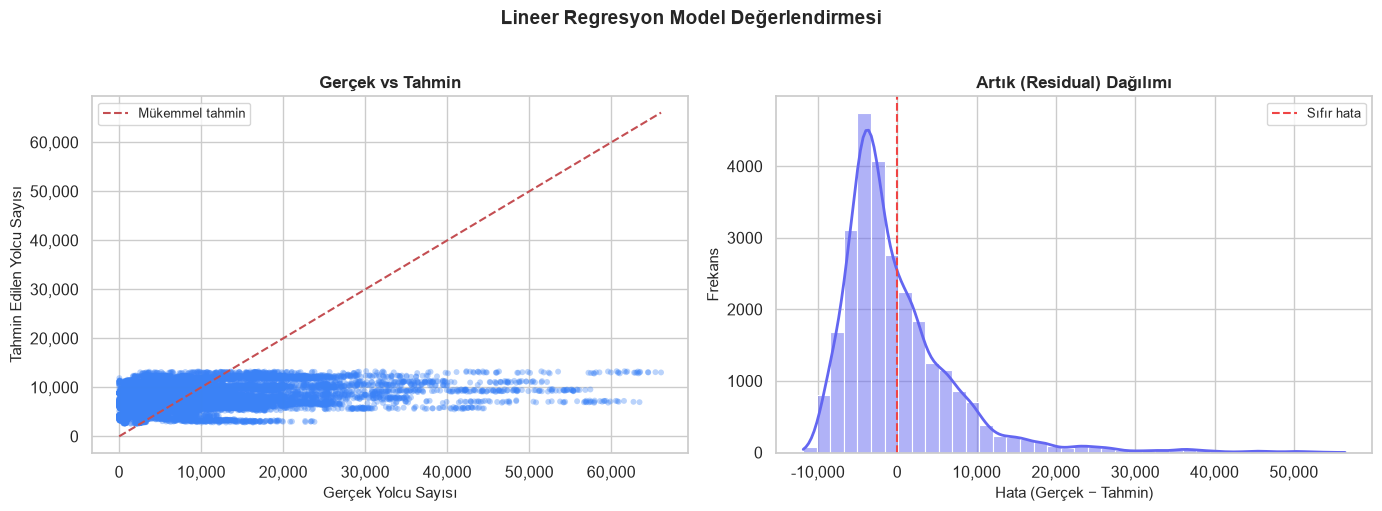


── Örnek Tahmin ──
  Medyan özellik değerleriyle tahmini yolcu sayısı: 7,524


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FILE_PATH = "rayli_sistemler_temiz.csv"  # Dosya yolunu güncelle

df = pd.read_csv(FILE_PATH, sep=None, engine="python", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

print("=" * 60)
print("VERİ YÜKLEME TAMAMLANDI")
print(f"Satır: {df.shape[0]:,}  |  Sütun: {df.shape[1]}")
print("=" * 60)

# =============================================================================
# 2. SÜTUN HAZIRLIĞI
# =============================================================================

# Gerekli sütunları sayısala çevir
sayisal = ["transaction_day", "transaction_month", "transaction_year", "passanger_cnt"]
for col in sayisal:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Hedef değişken ve gerekli sütunları filtrele
df = df.dropna(subset=["passanger_cnt", "transaction_day"])

# Hangi sütunlar mevcut → özellik listesini dinamik kur
ozellikler_sayisal = [c for c in ["transaction_day", "transaction_month", "transaction_year"] if c in df.columns]
ozellikler_kategorik = [c for c in ["line", "station_name", "town"] if c in df.columns]

print(f"\nKullanılacak sayısal özellikler : {ozellikler_sayisal}")
print(f"Kullanılacak kategorik özellikler: {ozellikler_kategorik}\n")

# =============================================================================
# 3. KATEGORİK DEĞİŞKENLERİ ENCODE ET (Label Encoding)
# =============================================================================

df_model = df[ozellikler_sayisal + ozellikler_kategorik + ["passanger_cnt"]].copy()

encoder_bilgisi = {}  # hangi etiketin hangi sayıya karşılık geldiğini sakla

print("── Kategorik Encoding ──")
for col in ozellikler_kategorik:
    df_model[col] = df_model[col].astype(str).str.strip()
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoder_bilgisi[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  {col}: {len(le.classes_)} benzersiz değer encode edildi")

# =============================================================================
# 4. EĞİTİM / TEST BÖLÜMÜ
# =============================================================================

X = df_model[ozellikler_sayisal + ozellikler_kategorik]
y = df_model["passanger_cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n── Veri Bölümü ──")
print(f"  Eğitim seti : {X_train.shape[0]:,} kayıt")
print(f"  Test seti   : {X_test.shape[0]:,} kayıt")

# =============================================================================
# 5. MODEL EĞİTİMİ
# =============================================================================

model = LinearRegression()
model.fit(X_train, y_train)

print("\n── Model Eğitimi Tamamlandı ──")

# =============================================================================
# 6. PERFORMANS DEĞERLENDİRME
# =============================================================================

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL PERFORMANS SONUÇLARI")
print("=" * 60)
print(f"  MAE  (Ortalama Mutlak Hata)  : {mae:>12,.2f} yolcu")
print(f"  RMSE (Kök Ortalama Kare Hata): {rmse:>12,.2f} yolcu")
print(f"  R²   (Açıklama Gücü)         : {r2:>12.4f}  ({r2*100:.1f}%)")
print("=" * 60)

if r2 >= 0.7:
    print("  ✓ Model verinin büyük bölümünü açıklıyor.")
elif r2 >= 0.4:
    print("  ⚠ Model orta düzeyde açıklama gücüne sahip.")
else:
    print("  ✗ Model düşük açıklama gücünde — ek özellik veya farklı algoritma dene.")

# =============================================================================
# 7. KATSAYI TABLOSU
# =============================================================================

katsayilar = pd.DataFrame({
    "Özellik"  : X.columns,
    "Katsayı"  : model.coef_
}).sort_values("Katsayı", key=abs, ascending=False)

print("\n── Özellik Katsayıları (etkiye göre sıralı) ──")
print(katsayilar.to_string(index=False))
print(f"\n  Sabit terim (intercept): {model.intercept_:,.2f}")

# =============================================================================
# 8. GÖRSELLEŞTİRME
# =============================================================================

sns.set_theme(style="whitegrid", font_scale=1.05)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafik 1: Gerçek vs Tahmin ---
ax1 = axes[0]
ax1.scatter(y_test, y_pred, alpha=0.35, s=18, color="#3B82F6", edgecolors="none")
lim_min = min(y_test.min(), y_pred.min())
lim_max = max(y_test.max(), y_pred.max())
ax1.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.5, label="Mükemmel tahmin")
ax1.set_xlabel("Gerçek Yolcu Sayısı", fontsize=11)
ax1.set_ylabel("Tahmin Edilen Yolcu Sayısı", fontsize=11)
ax1.set_title("Gerçek vs Tahmin", fontsize=12, fontweight="bold")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.legend(fontsize=9)

# --- Grafik 2: Artık (Residual) Dağılımı ---
ax2 = axes[1]
artiklar = y_test - y_pred
sns.histplot(artiklar, bins=40, ax=ax2, color="#6366F1", kde=True,
             line_kws={"linewidth": 2})
ax2.axvline(0, color="#EF4444", linestyle="--", linewidth=1.5, label="Sıfır hata")
ax2.set_xlabel("Hata (Gerçek − Tahmin)", fontsize=11)
ax2.set_ylabel("Frekans", fontsize=11)
ax2.set_title("Artık (Residual) Dağılımı", fontsize=12, fontweight="bold")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax2.legend(fontsize=9)

plt.suptitle(
    "Lineer Regresyon Model Değerlendirmesi",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()

OUTPUT = "lineer_regresyon_sonuc.png"
plt.savefig(OUTPUT, dpi=150, bbox_inches="tight")
print(f"\n✓ Grafik '{OUTPUT}' olarak kaydedildi.")
plt.show()

# =============================================================================
# 9. ÖRNEK TAHMİN
# =============================================================================

print("\n── Örnek Tahmin ──")
ornek = pd.DataFrame([{
    col: X_train[col].median() for col in X.columns
}])
tahmin = model.predict(ornek)[0]
print(f"  Medyan özellik değerleriyle tahmini yolcu sayısı: {tahmin:,.0f}")